In [1]:
import napari
from tifffile import imread
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import trackpy as tp

%matplotlib inline
%load_ext autoreload
%autoreload 2

In [2]:
# Load image

image = imread('/tungstenfs/scratch/gchao/bamfaile/Analysis/TUBB2B-KI/Batch20230223/D21/Denoised/Masks_created/100tp_561-100-50ms-1000g_4_conf561_merged.tif')
# In this image, ROI 9 shows detected spots that are high background rather than spots - can morphological appearance (eccentricity)
# of spot be used to do more filtering of bad quality / false-positive spots?

In [3]:
print(image.dtype, image.shape, np.min(image), np.max(image))

uint16 (100, 2, 1024, 1024) 5 49969


In [4]:
# Loads image mask

image_mask = imread('/tungstenfs/scratch/gchao/bamfaile/Analysis/TUBB2B-KI/Batch20230223/D21/ROIs/ROIs_as_mask_BIOP/100tp_561-100-50ms-1000g_4_conf561_merged_ROIs.tif')

In [5]:
print(image_mask.dtype, image_mask.shape)

uint8 (1024, 1024)


In [6]:
# Initializes Napari viewer

viewer = napari.Viewer()

In [7]:
# Adds image to Napari viewer

viewer.add_image(image)

<Image layer 'image' at 0x7f52b45b8d60>

In [8]:
# Adds mask image to Napari viewer

viewer.add_image(image_mask,
                 colormap="gist_earth",
                 contrast_limits=[0,8],
                 opacity=0.2)

<Image layer 'image_mask' at 0x7f51a46f1820>

In [9]:
# Loads detected spots

spots_path = r"/tungstenfs/scratch/gchao/bamfaile/Analysis/TUBB2B-KI/Batch20230223/D21/Spotdetection_tracking/Spotdetection/100tp_561-100-50ms-1000g_4_conf561_merged_spots.csv"
spots = pd.read_csv(spots_path)
spots.head()

,frame,roi_id,x,y,bg_denoised,amp_denoised,sigma_y,sigma_x,mean_spot_intensity
0,0,1,240.354808,700.247277,4911.314072,10202.557700,1.393954,1.229846,1323.055556
1,0,1,223.136631,708.928794,4014.206405,5122.043154,1.647806,1.314527,934.944444
2,0,2,292.785617,743.488423,3728.018242,9308.081718,1.466558,1.485174,1193.055556
3,0,2,292.631967,747.861612,4724.718264,4837.000000,2.080418,1.883072,1155.944444
4,0,2,266.276299,796.528192,5243.300322,13699.883220,1.400168,1.377884,1709.083333


In [10]:
# Creates df that contains xyct axes in the same order as image --> tcxy

spots_tcyxcoord = spots.iloc[:, np.r_[0,3,2]]
spots_tcyxcoord.insert(1, "channel", 0)
spots_tcyxcoord

,frame,channel,y,x
0,0,0,700.247277,240.354808
1,0,0,708.928794,223.136631
2,0,0,743.488423,292.785617
3,0,0,747.861612,292.631967
4,0,0,796.528192,266.276299
...,...,...,...,...
6578,99,0,44.912374,537.474446
6579,99,0,48.093247,557.363611
6580,99,0,54.524797,554.010255
6581,99,0,56.296007,546.482398


In [11]:
# Creates array from df (necessary to use in the points layer of Napari)

spots_tcyxarray = spots_tcyxcoord.to_numpy()
spots_tcyxarray

array([[  0.        ,   0.        , 700.24727702, 240.3548077 ],
       [  0.        ,   0.        , 708.92879426, 223.13663087],
       [  0.        ,   0.        , 743.48842261, 292.78561721],
       ...,
       [ 99.        ,   0.        ,  54.52479685, 554.01025476],
       [ 99.        ,   0.        ,  56.29600666, 546.4823976 ],
       [ 99.        ,   0.        ,  59.72917203, 587.5171558 ]])

In [12]:
# Adds detected spots to points layer

viewer.add_points(spots_tcyxcoord,
                  face_color='#ffffff00',
                  edge_color='magenta')

<Points layer 'Points' at 0x7f51a44bf7f0>

In [13]:
# Function to split table by ROI for tracking

def split_table_by_roi_id(df):
    """
    Splits each spots file into seperate dfs by roi-id, so that tracking can be done per ROI 
    """
    df = df.groupby("roi_id", sort = False, as_index = False)
    
    return df

In [14]:
#Splits table by ROI

spots_per_ROI = [j for i,j in split_table_by_roi_id(spots)]
spots_per_ROI[0].head(10)

,frame,roi_id,x,y,bg_denoised,amp_denoised,sigma_y,sigma_x,mean_spot_intensity
0,0,1,240.354808,700.247277,4911.314072,10202.557700,1.393954,1.229846,1323.055556
1,0,1,223.136631,708.928794,4014.206405,5122.043154,1.647806,1.314527,934.944444
54,1,1,225.587597,691.852900,3612.544331,3790.500000,2.326372,2.053595,898.027778
55,1,1,240.641595,700.662313,4968.520453,10962.269196,1.241646,1.156954,1553.083333
56,1,1,222.966845,709.648257,3948.350167,8244.582731,1.345105,1.342684,1231.333333
111,2,1,225.225460,690.897935,4043.868035,4137.500000,1.677393,1.692014,797.277778
112,2,1,240.328955,700.741154,5583.280788,6133.569507,1.439603,1.193348,1110.166667
113,2,1,223.240643,708.248292,3843.506164,6778.113953,1.673037,1.371738,973.361111
164,3,1,223.938789,700.503921,3596.243682,3625.000000,2.422899,2.132094,737.250000
165,3,1,223.129291,708.149788,3602.582698,8881.567330,1.451628,1.226924,1068.472222


In [15]:
# Links spots for all ROIs, filters them by minimum track length (default: 4 frames)
# Concatenates results of single ROIs into one df
# First number in df name stands for the distance in pixels that two spots can be apart, second number stands for how
# many frames a spot can be missing, before it will not be assigned to the same track anymore

tracks_per_ROI_5_3 = []

for df in spots_per_ROI:
    df = tp.link(df, 5, memory = 3)
    df.index._name = 'index'
    df = tp.filter_stubs(df, 4)
    tracks_per_ROI_5_3.append(df)

all_tracks_5_3 = pd.concat(tracks_per_ROI_5_3)

all_tracks_5_3.head(10)

Frame 17: 2 trajectories present.


IOPub message rate exceeded.
The notebook server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--NotebookApp.iopub_msg_rate_limit`.

Current values:
NotebookApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
NotebookApp.rate_limit_window=3.0 (secs)



In [16]:
all_tracks_5_3.head(10)

,frame,roi_id,x,y,bg_denoised,amp_denoised,sigma_y,sigma_x,mean_spot_intensity,particle
frame,,,,,,,,,,
0,0,1,240.354808,700.247277,4911.314072,10202.557700,1.393954,1.229846,1323.055556,0
0,0,1,223.136631,708.928794,4014.206405,5122.043154,1.647806,1.314527,934.944444,1
1,1,1,225.587597,691.852900,3612.544331,3790.500000,2.326372,2.053595,898.027778,2
1,1,1,240.641595,700.662313,4968.520453,10962.269196,1.241646,1.156954,1553.083333,0
1,1,1,222.966845,709.648257,3948.350167,8244.582731,1.345105,1.342684,1231.333333,1
2,2,1,225.225460,690.897935,4043.868035,4137.500000,1.677393,1.692014,797.277778,2
2,2,1,240.328955,700.741154,5583.280788,6133.569507,1.439603,1.193348,1110.166667,0
2,2,1,223.240643,708.248292,3843.506164,6778.113953,1.673037,1.371738,973.361111,1
3,3,1,223.938789,700.503921,3596.243682,3625.000000,2.422899,2.132094,737.250000,3


In [17]:
# Takes columns "particle", "frame", "x", "y" and sorts into format required by napari for visualization
# Inserts channel information right before y and x coordinate, according to image dimensions

all_tracks_5_3_sorted = all_tracks_5_3.iloc[:, np.r_[9,0,3,2]].sort_values("particle")
all_tracks_5_3_sorted.insert(2, "channel", 0)
all_tracks_5_3_sorted.head(20)

,particle,frame,channel,y,x
frame,,,,,
0,0,0,0,700.247277,240.354808
22,0,22,0,87.762932,383.694780
23,0,23,0,88.171410,384.153472
24,0,24,0,87.764003,384.172136
25,0,25,0,86.961160,384.016419
26,0,26,0,87.373348,383.739544
27,0,27,0,86.827581,383.775796
31,0,31,0,748.877420,291.443325
28,0,28,0,86.278921,383.711921


In [18]:
# For single ROIs
# Takes columns "particle", "frame", "x", "y" and sorts into format required by napari for visualization
# Inserts channel information right before y and x coordinate, according to image dimensions

tracks_per_ROI_5_3_sorted = []

for df in tracks_per_ROI_5_3:
    df = df.iloc[:, np.r_[9,0,3,2]].sort_values("particle") 
    tracks_per_ROI_5_3_sorted.append(df)
tracks_per_ROI_5_3_sorted[0].head(20)

,particle,frame,y,x
frame,,,,
0,0,0,700.247277,240.354808
1,0,1,700.662313,240.641595
7,0,7,700.643870,242.417204
2,0,2,700.741154,240.328955
6,0,6,699.535816,242.954435
5,0,5,699.444406,242.618622
4,0,4,698.722484,242.851238
12,1,12,713.021312,226.679069
11,1,11,714.040827,227.097410


In [19]:
# For single ROIs
# Inserts channel information right before y and x coordinate, according to image dimensions

for df in tracks_per_ROI_5_3_sorted:
    df = df.insert(2, "channel", 0)
tracks_per_ROI_5_3_sorted[0].head()


,particle,frame,channel,y,x
frame,,,,,
0,0,0,0,700.247277,240.354808
1,0,1,0,700.662313,240.641595
7,0,7,0,700.643870,242.417204
2,0,2,0,700.741154,240.328955
6,0,6,0,699.535816,242.954435


In [20]:
# Creates array from df (necessary to use in the points layer of Napari)

tracks_per_ROI_5_3_array = []
for df in tracks_per_ROI_5_3_sorted:
    df = df.to_numpy()
    tracks_per_ROI_5_3_array.append(df)
tracks_per_ROI_5_3_array[0]

array([[  0.        ,   0.        ,   0.        , 700.24727702,
        240.3548077 ],
       [  0.        ,   1.        ,   0.        , 700.66231252,
        240.64159525],
       [  0.        ,   7.        ,   0.        , 700.64387025,
        242.41720372],
       ...,
       [ 13.        ,  86.        ,   0.        , 711.32901257,
        226.74691326],
       [ 13.        ,  87.        ,   0.        , 711.70811021,
        228.10527484],
       [ 13.        ,  74.        ,   0.        , 711.4059258 ,
        225.91396069]])

In [21]:
# Adds tracks of all ROIs into Napari viewer as seperate track layers

for df in tracks_per_ROI_5_3_array:
    viewer.add_tracks(df, name='tracks', tail_length=15)

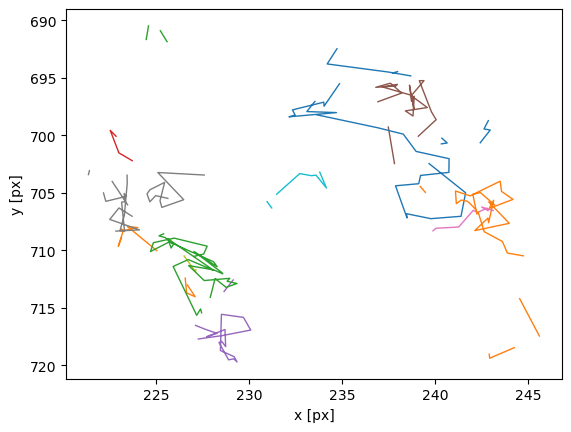

In [22]:
plt.figure()
tp.plot_traj(tracks_per_ROI_5_3_sorted[0]);

In [23]:
tracks_per_ROI_5_3_sorted[0]['particle'].values

array([ 0,  0,  0,  0,  0,  0,  0,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  2,  2,  2,  2,  3,  3,  3,  3,  3,  4,  4,  4,  4,  4,  4,
        4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  5,  5,  5,
        5,  5,  5,  5,  5,  5,  5,  5,  5,  5,  5,  5,  5,  5,  5,  5,  5,
        5,  5,  5,  5,  6,  6,  6,  6,  6,  6,  6,  6,  6,  7,  7,  7,  7,
        7,  7,  7,  7,  7,  7,  7,  7,  7,  7,  7,  7,  7,  7,  7,  7,  7,
        7,  7,  7,  7,  7,  7,  7,  7,  7,  7,  7,  7,  7,  9,  9,  9,  9,
       10, 10, 10, 10, 10, 10, 10, 10, 11, 11, 11, 11, 11, 11, 11, 11, 11,
       11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11,
       11, 11, 11, 11, 11, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12,
       12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12,
       12, 12, 12, 12, 12, 12, 12, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13,
       13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13,
       13, 13, 13, 13, 13

In [24]:
from matplotlib import cm

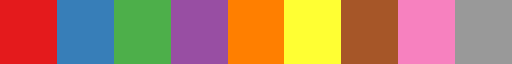

In [25]:
cm.Set1

In [26]:
all_tracks_ = all_tracks_5_3[['particle', 'frame', 'y', 'x']]
all_tracks_.insert(2, "channel", 0)

In [27]:
all_tracks_.index.name='id'

In [28]:
all_tracks_.sort_values(['particle', 'frame'])

,particle,frame,channel,y,x
id,,,,,
0,0,0,0,700.247277,240.354808
0,0,0,0,743.488423,292.785617
0,0,0,0,745.161531,345.156093
0,0,0,0,784.021788,451.848991
0,0,0,0,518.194297,335.630883
...,...,...,...,...,...
94,76,94,0,599.330373,398.512790
95,76,95,0,600.516518,399.672012
96,76,96,0,599.527457,399.785441


In [29]:
def create_track_id(row):
    return f"{row['roi_id']}_{row['particle']}"

In [30]:
all_tracks_5_3['track-id'] = all_tracks_5_3.apply(create_track_id, axis=1)

In [31]:
all_tracks_5_3.index._name = 'index'
all_tracks_5_3.sort_values(['track-id', 'frame'])

,frame,roi_id,x,y,bg_denoised,amp_denoised,sigma_y,sigma_x,mean_spot_intensity,particle,track-id
index,,,,,,,,,,,
0,0,1,240.354808,700.247277,4911.314072,10202.557700,1.393954,1.229846,1323.055556,0,1.0_0.0
1,1,1,240.641595,700.662313,4968.520453,10962.269196,1.241646,1.156954,1553.083333,0,1.0_0.0
2,2,1,240.328955,700.741154,5583.280788,6133.569507,1.439603,1.193348,1110.166667,0,1.0_0.0
4,4,1,242.851238,698.722484,5135.884129,6957.468183,1.261824,1.509359,1119.916667,0,1.0_0.0
5,5,1,242.618622,699.444406,4381.751535,8336.041280,1.491042,1.213166,1067.305556,0,1.0_0.0
...,...,...,...,...,...,...,...,...,...,...,...
41,41,9,443.401358,498.736277,3989.701291,17145.324487,1.298544,1.337449,1600.916667,9,9.0_9.0
42,42,9,442.488971,499.508571,4304.899478,9712.372880,1.692123,1.334239,1085.722222,9,9.0_9.0
43,43,9,442.814497,499.443341,3657.237269,10609.922933,1.450644,1.629827,1291.138889,9,9.0_9.0


In [32]:
track_ids = all_tracks_5_3['track-id'].unique()

In [33]:
track_ids

array(['1.0_0.0', '1.0_1.0', '1.0_2.0', '1.0_3.0', '1.0_4.0', '1.0_5.0',
       '1.0_6.0', '1.0_7.0', '1.0_9.0', '1.0_10.0', '1.0_11.0',
       '1.0_12.0', '1.0_13.0', '2.0_0.0', '2.0_2.0', '2.0_4.0', '2.0_5.0',
       '2.0_9.0', '2.0_10.0', '2.0_11.0', '2.0_12.0', '2.0_16.0',
       '2.0_18.0', '2.0_19.0', '2.0_21.0', '2.0_23.0', '2.0_24.0',
       '2.0_26.0', '2.0_28.0', '2.0_31.0', '2.0_34.0', '2.0_40.0',
       '2.0_41.0', '2.0_44.0', '3.0_1.0', '3.0_2.0', '3.0_3.0',
       '3.0_10.0', '3.0_11.0', '3.0_12.0', '3.0_13.0', '3.0_15.0',
       '3.0_21.0', '3.0_22.0', '3.0_24.0', '3.0_28.0', '4.0_3.0',
       '4.0_4.0', '4.0_5.0', '4.0_6.0', '4.0_7.0', '4.0_9.0', '4.0_10.0',
       '4.0_12.0', '4.0_14.0', '4.0_15.0', '4.0_18.0', '4.0_19.0',
       '4.0_20.0', '4.0_21.0', '4.0_22.0', '4.0_23.0', '4.0_25.0',
       '4.0_28.0', '4.0_29.0', '4.0_33.0', '4.0_34.0', '4.0_35.0',
       '4.0_39.0', '4.0_40.0', '4.0_41.0', '4.0_42.0', '4.0_43.0',
       '4.0_46.0', '4.0_49.0', '4.0_50.0', '4.0_5

In [34]:
all_tracks_5_3 = all_tracks_5_3.replace(to_replace=track_ids, value=np.random.permutation(len(track_ids)))

In [35]:
all_tracks_5_3.insert(2, "channel", 0)

In [36]:
len(all_tracks_5_3)

5934

In [37]:
viewer.add_tracks(all_tracks_5_3[['track-id', 'frame', 'channel', 'y', 'x']], name='tracks', 
                  properties={
                      'id': all_tracks_5_3['track-id'].values,
                             },
                  color_by='id',
                  colormap='hsv', 
                 )

/home/tibuch/Gitrepos/gchao_singlemolecule_tracking/infrastructure/apps/micromamba/envs/tracking_analysis/lib/python3.9/site-packages/napari/layers/tracks/tracks.py:620: UserWarning: Previous color_by key 'id' not present in features. Falling back to track_id
  warn(


<Tracks layer 'tracks [18]' at 0x7f516823c310>

In [38]:
viewer.add_tracks(all_tracks_5_3[['track-id', 'frame', 'channel', 'y', 'x']], name='tracks', 
colormap='blue'
                 )

<Tracks layer 'tracks [19]' at 0x7f516823ff10>